# Filter tuning

This notebook focuses only on a **linear Kalman filter (KF)** for a simple 2D
constant-velocity model.

The main goal is not just to run the filter once, but to show how the estimation
changes when we iterate on the tuning parameters:

$$
Q \quad \text{(process noise covariance)}, \qquad
R \quad \text{(measurement noise covariance)}, \qquad
P_0 \quad \text{(initial state covariance)}.
$$

We will use a standard linear discrete-time model:

$$
x_k =
\begin{bmatrix}
p_{x,k} \\
p_{y,k} \\
v_{x,k} \\
v_{y,k}
\end{bmatrix},
\qquad
z_k =
\begin{bmatrix}
p_{x,k} \\
p_{y,k}
\end{bmatrix}.
$$

The state dynamics are

$$
x_{k+1} = F x_k + w_k,
\qquad
w_k \sim \mathcal{N}(0,Q),
$$

and the measurements satisfy

$$
z_k = H x_k + v_k,
\qquad
v_k \sim \mathcal{N}(0,R).
$$

The notebook compares several tuning iterations and shows how to reason about them.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. System model

We use a standard constant-velocity model in 2D:

$$
F =
\begin{bmatrix}
1 & 0 & dt & 0 \\
0 & 1 & 0 & dt \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

In [2]:
np.random.seed(7)

dt = 1.0
num_steps = 70

F = np.array([
    [1.0, 0.0, dt,  0.0],
    [0.0, 1.0, 0.0, dt ],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)

H = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
], dtype=float)

I = np.eye(4)

## 3. Simulate a trajectory

To make tuning meaningful, we simulate a trajectory that is *mostly* constant-velocity but contains a maneuver.
This creates a situation where the value of \(Q\) matters.

The true state is

$$
x_k =
\begin{bmatrix}
p_x & p_y & v_x & v_y
\end{bmatrix}^\top.
$$

In [4]:
x_true = np.array([0.0, 0.0, 1.2, 0.6], dtype=float)

true_states = []

for k in range(num_steps):
    if k == 20:
        x_true[2] += 0.5
        x_true[3] -= 0.25

    if k == 45:
        x_true[2] -= 0.6
        x_true[3] += 0.4

    x_true = F @ x_true
    true_states.append(x_true.copy())

true_states = np.array(true_states)
true_positions = true_states[:, :2]

## 4. Generate noisy measurements

We simulate noisy position measurements:

$$
z_k = Hx_k + v_k.
$$

The actual measurement noise standard deviation used in the simulation is stored below.

In [5]:
measurement_std_true = 2.0
measurements = true_positions + measurement_std_true * np.random.randn(num_steps, 2)

## 5. Kalman filter implementation

The linear KF prediction and update equations are

$$
\hat{x}_{k|k-1} = F\hat{x}_{k-1|k-1}
$$

$$
P_{k|k-1} = F P_{k-1|k-1} F^\top + Q
$$

$$
y_k = z_k - H\hat{x}_{k|k-1}
$$

$$
S_k = H P_{k|k-1} H^\top + R
$$

$$
K_k = P_{k|k-1} H^\top S_k^{-1}
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
$$

$$
P_{k|k} = (I-K_kH)P_{k|k-1}.
$$

In [6]:
def make_process_covariance(q, dt):
    return q * np.array([
        [dt**4/4, 0.0,      dt**3/2, 0.0],
        [0.0,      dt**4/4, 0.0,      dt**3/2],
        [dt**3/2,  0.0,     dt**2,    0.0],
        [0.0,      dt**3/2, 0.0,      dt**2],
    ], dtype=float)

def run_kf(measurements, F, H, Q, R, x0, P0):
    I = np.eye(F.shape[0])
    x_est = x0.copy().astype(float)
    P = P0.copy().astype(float)

    xs = []
    innovations = []
    innovation_norms = []
    innovations_covs = []

    for z in measurements:
        x_pred = F @ x_est
        P_pred = F @ P @ F.T + Q

        y = z - (H @ x_pred)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_est = x_pred + K @ y
        P = (I - K @ H) @ P_pred

        xs.append(x_est.copy())
        innovations.append(y.copy())
        innovation_norms.append(float(np.linalg.norm(y)))
        innovations_covs.append(S)

    return np.array(xs), np.array(innovations), np.array(innovation_norms), np.array(innovations_covs)

def position_rmse(est_states, true_states):
    return float(np.sqrt(np.mean(np.sum((est_states[:, :2] - true_states[:, :2])**2, axis=1))))

def velocity_rmse(est_states, true_states):
    return float(np.sqrt(np.mean(np.sum((est_states[:, 2:] - true_states[:, 2:])**2, axis=1))))

## 6. Initial guess and tuning philosophy

We will start from an intentionally rough initialization:

$$
\hat{x}_{0|0} =
\begin{bmatrix}
0 \\ 0 \\ 0 \\ 0
\end{bmatrix}.
$$

Then we will try a few tuning iterations.

Typical interpretation:

- **\(Q\) too small**: the filter trusts the model too much and reacts slowly to maneuvers.
- **\(Q\) too large**: the filter becomes nervous and follows measurement noise too much.
- **\(R\) too small**: the filter trusts measurements too much.
- **\(R\) too large**: the filter becomes overly smooth and lags.
- **\(P_0\)** controls how strongly the filter trusts its initial state.

In [7]:
x0 = np.array([0.0, 0.0, 0.0, 0.0], dtype=float)
P0_base = np.diag([25.0, 25.0, 9.0, 9.0])

## 7. Define tuning iterations

We create several iterations to illustrate a tuning workflow.

### Iteration 1
Very small process noise \(Q\), moderate \(R\).  
Expected behavior: smooth estimate, but too much lag during maneuvers.

### Iteration 2
Larger \(Q\), same \(R\).  
Expected behavior: more responsive to unmodeled changes.

### Iteration 3
Reasonable \(Q\), but underestimated \(R\).  
Expected behavior: estimate follows measurements too aggressively.

### Iteration 4
Reasonable \(Q\), but overestimated \(R\).  
Expected behavior: estimate becomes too conservative.

### Iteration 5
Same \(Q\) and \(R\) as a good candidate, but different \(P_0\).  
Expected behavior: early transients change even if steady-state behavior is similar.

In [8]:
iterations = [
    {
        "name": "Iter 1: Q too small",
        "q": 0.01,
        "r_std": 2.0,
        "P0": P0_base,
        "comment": "Model trusted too much; likely lag during maneuvers."
    },
    {
        "name": "Iter 2: better Q",
        "q": 0.18,
        "r_std": 2.0,
        "P0": P0_base,
        "comment": "More responsive to maneuvering."
    },
    {
        "name": "Iter 3: R too small",
        "q": 0.18,
        "r_std": 0.8,
        "P0": P0_base,
        "comment": "Measurements trusted too much; estimate may become noisy."
    },
    {
        "name": "Iter 4: R too large",
        "q": 0.18,
        "r_std": 4.0,
        "P0": P0_base,
        "comment": "Measurements trusted too little; estimate may lag."
    },
    {
        "name": "Iter 5: tuned Q,R with smaller P0",
        "q": 0.18,
        "r_std": 2.0,
        "P0": np.diag([4.0, 4.0, 1.0, 1.0]),
        "comment": "Same main tuning, but more confidence in the initial guess."
    },
]

## 8. Run all tuning iterations

In [9]:
results = []

for cfg in iterations:
    Q = make_process_covariance(cfg["q"], dt)
    R = np.diag([cfg["r_std"]**2, cfg["r_std"]**2])

    est_states, innovations, innovation_norms, innovations_covs = run_kf(
        measurements=measurements,
        F=F,
        H=H,
        Q=Q,
        R=R,
        x0=x0,
        P0=cfg["P0"]
    )

    results.append({
        "name": cfg["name"],
        "comment": cfg["comment"],
        "Q": Q,
        "R": R,
        "P0": cfg["P0"],
        "est_states": est_states,
        "innovations": innovations,
        "innovation_norms": innovation_norms,
        "innovations_covs": innovations_covs,
        "pos_rmse": position_rmse(est_states, true_states),
        "vel_rmse": velocity_rmse(est_states, true_states),
    })

## 9. Quantitative comparison

In [10]:
for r in results:
    print(r["name"])
    print(f"  Position RMSE: {r['pos_rmse']:.3f} m")
    print(f"  Velocity RMSE: {r['vel_rmse']:.3f} m/s")
    print(f"  Note: {r['comment']}")
    print()

Iter 1: Q too small
  Position RMSE: 1.369 m
  Velocity RMSE: 0.419 m/s
  Note: Model trusted too much; likely lag during maneuvers.

Iter 2: better Q
  Position RMSE: 1.638 m
  Velocity RMSE: 0.581 m/s
  Note: More responsive to maneuvering.

Iter 3: R too small
  Position RMSE: 1.998 m
  Velocity RMSE: 1.094 m/s
  Note: Measurements trusted too much; estimate may become noisy.

Iter 4: R too large
  Position RMSE: 1.393 m
  Velocity RMSE: 0.374 m/s
  Note: Measurements trusted too little; estimate may lag.

Iter 5: tuned Q,R with smaller P0
  Position RMSE: 1.603 m
  Velocity RMSE: 0.528 m/s
  Note: Same main tuning, but more confidence in the initial guess.



## 10. Plot trajectory comparison

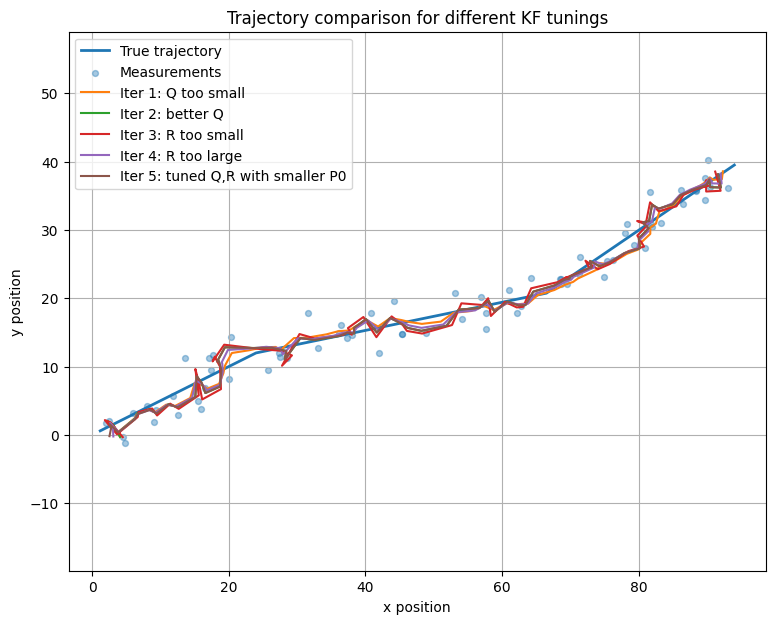

In [11]:
plt.figure(figsize=(9, 7))
plt.plot(true_positions[:, 0], true_positions[:, 1], label="True trajectory", linewidth=2)
plt.scatter(measurements[:, 0], measurements[:, 1], s=18, alpha=0.4, label="Measurements")

for r in results:
    xs = r["est_states"]
    plt.plot(xs[:, 0], xs[:, 1], label=r["name"])

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Trajectory comparison for different KF tunings")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

## 11. Compare the x-position estimate

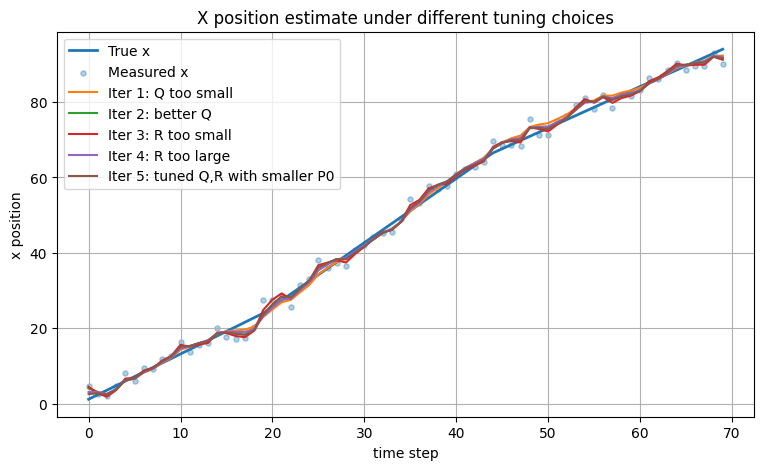

In [12]:
t = np.arange(num_steps)

plt.figure(figsize=(9, 5))
plt.plot(t, true_states[:, 0], label="True x", linewidth=2)
plt.scatter(t, measurements[:, 0], s=14, alpha=0.35, label="Measured x")

for r in results:
    plt.plot(t, r["est_states"][:, 0], label=r["name"])

plt.xlabel("time step")
plt.ylabel("x position")
plt.title("X position estimate under different tuning choices")
plt.grid(True)
plt.legend()
plt.show()

## 12. Compare the x-velocity estimate

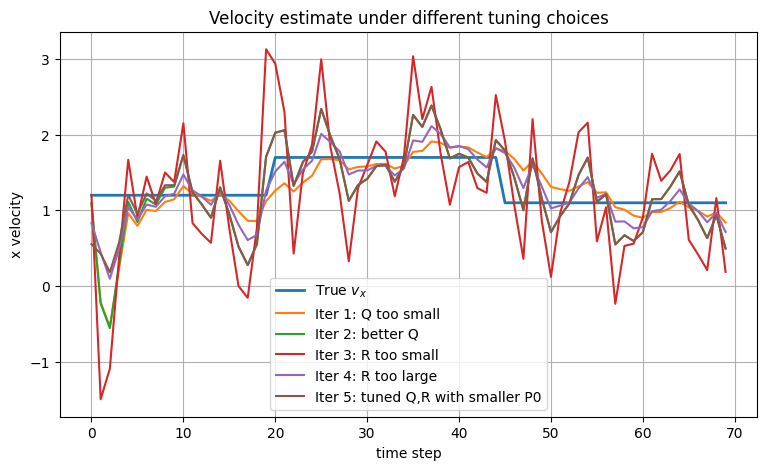

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(t, true_states[:, 2], label="True $v_x$", linewidth=2)

for r in results:
    plt.plot(t, r["est_states"][:, 2], label=r["name"])

plt.xlabel("time step")
plt.ylabel("x velocity")
plt.title("Velocity estimate under different tuning choices")
plt.grid(True)
plt.legend()
plt.show()

## 13. Innovation magnitude

A useful diagnostic is the innovation

$$
y_k = z_k - H\hat{x}_{k|k-1}.
$$

Large and structured innovations may indicate poor tuning or model mismatch.

Also, innovation whiteness can be checked. Simple check of mean and cov. But
also additional tests on auto-correlation and cross-correlation exists.

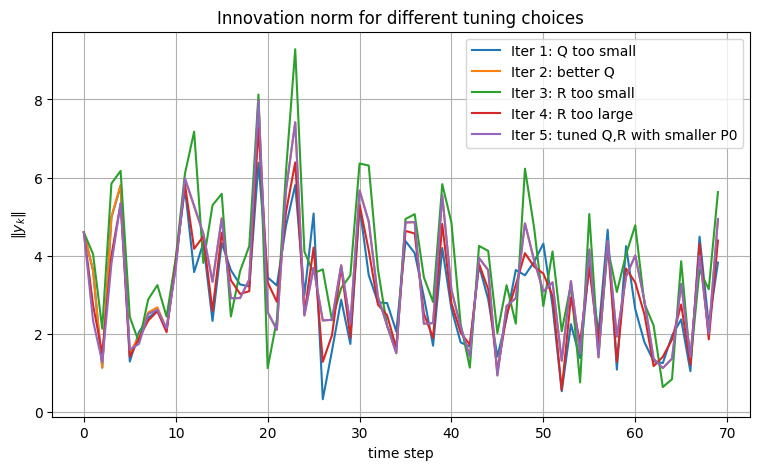

Iter 1: Q too small
    Sample mean: [0.0001829  0.01773306]
    Sample variance:
 [[0.92241251 0.02632581]
 [0.02632581 0.9872776 ]]

Iter 2: better Q
    Sample mean: [0.0095967  0.00818319]
    Sample variance:
 [[0.75883763 0.06950589]
 [0.06950589 0.92232644]]

Iter 3: R too small
    Sample mean: [0.03140852 0.01649015]
    Sample variance:
 [[4.05129616 0.44932727]
 [0.44932727 5.38029723]]

Iter 4: R too large
    Sample mean: [0.00552904 0.00746233]
    Sample variance:
 [[0.20872502 0.01525058]
 [0.01525058 0.23792599]]

Iter 5: tuned Q,R with smaller P0
    Sample mean: [0.01732677 0.01825542]
    Sample variance:
 [[0.77226283 0.0728809 ]
 [0.0728809  0.92394591]]



In [14]:
def normalized_innovation(innovation, S):
    """
    innovation: array of shape (N, 2)
    S:          array of shape (N, 2, 2)

    returns:
        nu_norm: array of shape (N, 2)
    """
    innovation = np.asarray(innovation)
    S = np.asarray(S)

    N = innovation.shape[0]
    nu_norm = np.empty_like(innovation, dtype=float)

    for k in range(N):
        # Cholesky: S[k] = L @ L.T
        L = np.linalg.cholesky(S[k])

        # Solve L x = innovation[k]
        nu_norm[k] = np.linalg.solve(L, innovation[k])

    return nu_norm


plt.figure(figsize=(9, 5))
for r in results:
    plt.plot(t, r["innovation_norms"], label=r["name"])

plt.xlabel("time step")
plt.ylabel(r"$\|y_k\|$")
plt.title("Innovation norm for different tuning choices")
plt.grid(True)
plt.legend()
plt.show()


for r in results:

    nu = r['innovations']
    S = r['innovations_covs']
    nu_normalized = normalized_innovation(nu, S)
    N = len(r['innovations'])

    # mean/cov check
    print(r['name'])
    print("    Sample mean:", np.mean(nu_normalized, axis=0))
    print("    Sample variance:\n", np.cov(nu_normalized, rowvar=False))
    print("")

## 14. A simple iterative tuning interpretation

A practical tuning loop often looks like this:

1. Start with a plausible \(R\) based on sensor knowledge.
2. Start with a small \(Q\).
3. If the filter lags during maneuvers, increase \(Q\).
4. If the estimate is too noisy and follows measurements too closely, increase \(R\) or decrease \(Q\).
5. Adjust \(P_0\) if the initial transient is too slow or too aggressive.

In this example:

- **Iteration 1** shows what happens when \(Q\) is too small.
- **Iteration 2** is often closer to a good compromise.
- **Iteration 3** shows the effect of underestimating \(R\).
- **Iteration 4** shows the effect of overestimating \(R\).
- **Iteration 5** shows how \(P_0\) mainly affects the early part of the run.

There is no universal best tuning: the “best” choice depends on model fidelity, sensor quality, and the behavior you want.

## 15. Optional exercise

Try modifying

$$
Q,\qquad R,\qquad P_0
$$

and observe how the filter behavior changes.

Good experiments include:

- increasing the true maneuver intensity,
- changing the measurement noise,
- starting from a worse initial velocity estimate,
- comparing position RMSE against velocity RMSE.